Coupled Aeroelastic Result Analysis

Loads diagnostics from `results/` and plots tip displacement, energies, work-conservation, and residual convergence.

In [14]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

ROOT = os.path.abspath(".")
RES = os.path.join(ROOT, "results/v12_v8_chordBC_allrowshedding/")
COUPLING_CSV = os.path.join(RES, "coupling_history.csv")
FLUID_DIAG = sorted(glob.glob(os.path.join(RES, "fluid_v8_coupling_diagnostics.csv")))
SOLID_DIAGS = sorted(glob.glob(os.path.join(RES, "solid_v12_diagnostics.csv")))

print("Results dir:", RES)
print("Coupling log:", COUPLING_CSV if os.path.exists(COUPLING_CSV) else "missing")
print("Fluid diagnostics:", FLUID_DIAG if FLUID_DIAG else "missing")
print("Solid diagnostics:", SOLID_DIAGS if SOLID_DIAGS else "missing")

Results dir: /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/v12_v8_chordBC_allrowshedding/
Coupling log: /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/v12_v8_chordBC_allrowshedding/coupling_history.csv
Fluid diagnostics: ['/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/v12_v8_chordBC_allrowshedding/fluid_v8_coupling_diagnostics.csv']
Solid diagnostics: ['/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/v12_v8_chordBC_allrowshedding/solid_v12_diagnostics.csv']


In [15]:
def load_csv(path):
    if path and os.path.exists(path):
        return pd.read_csv(path)
    return None

solid_data = {os.path.basename(p): load_csv(p) for p in SOLID_DIAGS}
fluid_data = {os.path.basename(p): load_csv(p) for p in FLUID_DIAG}
coupling_df = load_csv(COUPLING_CSV)

for k, df in solid_data.items():
    print(k, "rows=", 0 if df is None else len(df))
for k, df in fluid_data.items():
    print(k, "rows=", 0 if df is None else len(df))
if coupling_df is not None:
    print("coupling_history rows=", len(coupling_df))

EmptyDataError: No columns to parse from file

## Tip Displacement

In [ ]:
plt.figure()
plotted=False
for name, df in solid_data.items():
    if df is None or not {"time","u_tip"}.issubset(df.columns):
        continue
    plt.plot(df["time"], df["u_tip"], label=name.replace("_diagnostics.csv",""))
    plotted=True
if plotted:
    plt.xlabel("Time [s]")
    plt.ylabel("Tip displacement [m]")
    plt.legend()
    plt.title("Tip Displacement vs Time")
    plt.show()
    plt.savefig
else:
    print("No solid diagnostics with time/u_tip found.")

No solid diagnostics with time/u_tip found.


<Figure size 800x400 with 0 Axes>

## Energy Distribution

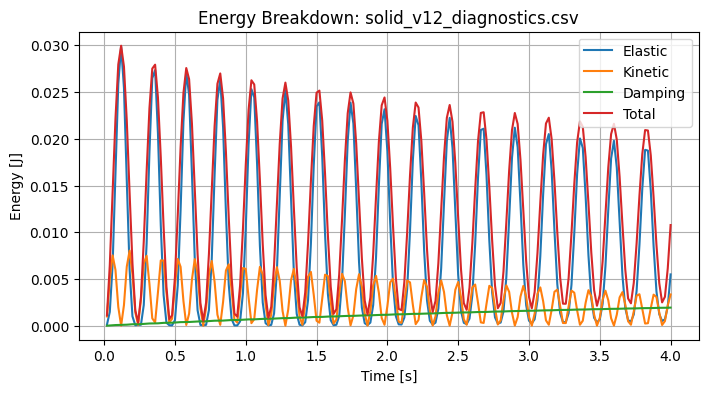

In [16]:
for name, df in solid_data.items():
    if df is None:
        continue
    req = {"time","E_elas","E_kin","E_damp","E_tot"}
    if not req.issubset(df.columns):
        continue
    plt.figure()
    plt.plot(df["time"], df["E_elas"], label="Elastic")
    plt.plot(df["time"], df["E_kin"], label="Kinetic")
    plt.plot(df["time"], df["E_damp"], label="Damping")
    plt.plot(df["time"], df["E_tot"], label="Total")
    plt.xlabel("Time [s]")
    plt.ylabel("Energy [J]")
    plt.legend()
    plt.title(f"Energy Breakdown: {name}")
    plt.show()
    plt.savefig

## Work Conservation Convergence

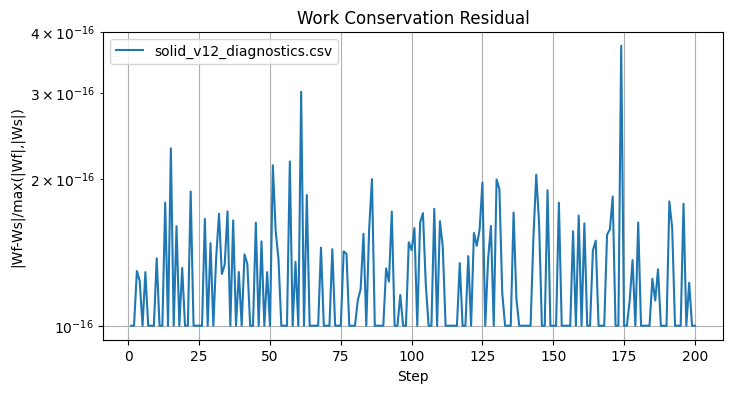

In [17]:
plt.figure()
plotted=False
for name, df in solid_data.items():
    if df is None or "work_rel_error" not in df.columns:
        continue
    y = np.abs(df["work_rel_error"].to_numpy())
    plt.semilogy(np.arange(1, len(y)+1), np.maximum(y, 1e-16), label=name)
    plotted=True
if plotted:
    plt.xlabel("Step")
    plt.ylabel("|Wf-Ws|/max(|Wf|,|Ws|)")
    plt.title("Work Conservation Residual")
    plt.legend()
    plt.show()
    plt.savefig
else:
    print("No work_rel_error columns found.")

## Solver Residual Convergence

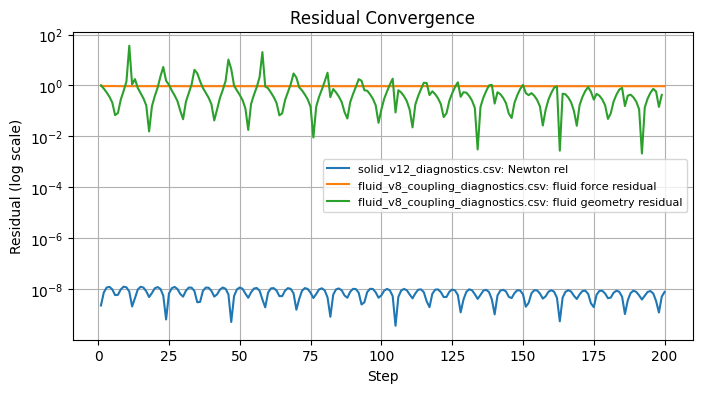

In [18]:
plt.figure()
plotted=False
for name, df in solid_data.items():
    if df is None:
        continue
    if "newton_rel" in df.columns:
        y = np.maximum(np.abs(df["newton_rel"].to_numpy()), 1e-16)
        plt.semilogy(np.arange(1, len(y)+1), y, label=f"{name}: Newton rel")
        plotted=True
    elif "disp_residual" in df.columns:
        y = np.maximum(np.abs(df["disp_residual"].to_numpy()), 1e-16)
        plt.semilogy(np.arange(1, len(y)+1), y, label=f"{name}: disp residual")
        plotted=True
if coupling_df is not None and "force_residual" in coupling_df.columns:
    y = np.maximum(np.abs(coupling_df["force_residual"].to_numpy()), 1e-16)
    plt.semilogy(coupling_df["step"], y, "--", label="coupling force residual")
    plotted=True
for name, df in fluid_data.items():
    if df is None:
        continue
    if "force_residual" in df.columns:
        y = np.maximum(np.abs(df["force_residual"].to_numpy()), 1e-16)
        plt.semilogy(df["step"], y, label=f"{name}: fluid force residual")
        plotted=True
    if "geometry_residual" in df.columns:
        y = np.maximum(np.abs(df["geometry_residual"].to_numpy()), 1e-16)
        plt.semilogy(df["step"], y, label=f"{name}: fluid geometry residual")
        plotted=True
if plotted:
    plt.xlabel("Step")
    plt.ylabel("Residual (log scale)")
    plt.title("Residual Convergence")
    plt.legend(loc="best", fontsize=8)
    plt.show()
    plt.savefig
else:
    print("No residual-like columns found.")

## Coupling / Time-Scale Checks

In [19]:
if coupling_df is not None:
    display(coupling_df.head())
    if {"force_relax_used","force_residual"}.issubset(coupling_df.columns):
        plt.figure()
        plt.plot(coupling_df["step"], coupling_df["force_relax_used"], label="force relaxation")
        plt.plot(coupling_df["step"], coupling_df["force_residual"], label="force residual")
        plt.xlabel("Step")
        plt.title("Coupling Relaxation / Residual")
        plt.legend()
        plt.show()
        plt.savefig
else:
    print("Coupling diagnostics CSV missing.")

Coupling diagnostics CSV missing.
